In [2]:
import torch 

In [7]:
A = torch.ones((2,3,4))

In [8]:
torch.linalg.norm(A, ood=)

tensor(4.8990)

In [4]:
import torch 
A= torch.rand((2,3,4))
print(f"Output across axis 0 : {A.sum(axis=0).shape}")
print(f"Output across axis 1 : {A.sum(axis=1).shape}")
print(f"Output across axis 2 : {A.sum(axis=2).shape}")

Output across axis 0 : torch.Size([3, 4])
Output across axis 1 : torch.Size([2, 4])
Output across axis 2 : torch.Size([2, 3])


In [11]:
torch.arange(8, dtype=torch.float).reshape(2, 2, 2)

tensor([[[0., 1.],
         [2., 3.]],

        [[4., 5.],
         [6., 7.]]])

In [1]:
import torch 
A = torch.zeros((100, 200))
B = torch.ones((100, 200))
C = B + B
stacked = torch.stack((A, B, C))
print(stacked.shape)

torch.Size([3, 100, 200])


In [2]:
(torch.stack([A,B,C])[1] == B).unique()

tensor([True])

In [22]:
%time 
first_result = A @ B

CPU times: user 5 μs, sys: 0 ns, total: 5 μs
Wall time: 9.54 μs


In [23]:
%time 
second_result = A @ C.T

CPU times: user 7 μs, sys: 0 ns, total: 7 μs
Wall time: 11.9 μs


In [24]:
%time 
C = B.T
third_result = A @ C.T 

CPU times: user 0 ns, sys: 5 μs, total: 5 μs
Wall time: 9.3 μs


In [7]:
x = (2,3,4)
len(x)

3

In [1]:
import torch 
X = torch.arange(24, dtype=torch.float64).reshape(2, 3, 4)
# If arguments ord and dim is not given then, the matrix is flattened and Frobenius norm
# (Euclidean Distance) of the entire element is computed. 
print(torch.linalg.norm(X))
print(torch.sqrt(torch.sum(X ** 2)))

tensor(65.7571, dtype=torch.float64)
tensor(65.7571, dtype=torch.float64)


In [2]:
# But we can also pass in dimension, (dim) argument and order (ord) argument
# fro calculates Frobenius norm across dimension 0 and 1 of the tensor, so we get 4 values. 
torch.linalg.norm(X, ord='fro', dim=(0,1))

tensor([29.6648, 31.7175, 33.8231, 35.9722], dtype=torch.float64)

In [3]:
# nuc calculates nuclear norm across dimension 1 and 2 of the tensor, so there is 2 values
torch.linalg.norm(X,ord='nuc', dim=(1, 2))

tensor([24.3646, 62.4951], dtype=torch.float64)

In [4]:
# If we don't specify ord argument, by default: fro benius norm is calculated
torch.linalg.norm(X, dim=(0))

tensor([[12.0000, 13.0384, 14.1421, 15.2971],
        [16.4924, 17.7200, 18.9737, 20.2485],
        [21.5407, 22.8473, 24.1661, 25.4951]], dtype=torch.float64)

In [1]:
import psutil
import time
import torch 

def memory(X, Y):
    start = time.time()
    torch.mm(X, Y)
    memory = psutil.virtual_memory()
    print(f"Total system memory: {memory.total / (1024 ** 3):.2f} GB")
    print(f"Memory used: {memory.used / (1024 ** 3):.2f} GB")
    print(f"Available memory: {memory.available / (1024 ** 3):.2f} GB")
    print(f"CPU usage: {psutil.cpu_percent():.2f}%")
    elapsed = time.time() - start
    print(f"Elapsed time: {elapsed:.2f} seconds\n")

torch.manual_seed(42)
A = torch.randn(2 ** 10, 2 ** 16, dtype=torch.float64)
B = torch.randn(2 ** 16, 2 ** 5, dtype=torch.float64)
C = torch.randn(2 ** 5, 2 ** 14, dtype=torch.float64)

In [2]:
memory(torch.mm(A, B), C)

Total system memory: 7.65 GB
Memory used: 2.55 GB
Available memory: 4.34 GB
CPU usage: 6.00%
Elapsed time: 0.11 seconds



In [ ]:
memory(A, torch.mm(B, C))

In [65]:
import torch 

In [73]:
def f(a):
    b = a * 2
    while b.norm() < 1000:
        b = b * 2
    if b.sum() > 0:
        c = b
    else:
        c = 100 * b
    return c

In [82]:
a = torch.randn(size=(1,2), requires_grad=True)
print(a)
d = f(a)
print(d)
d.mean().backward()

tensor([[-0.3933, -0.9025]], requires_grad=True)
tensor([[-40270.0977, -92420.1797]], grad_fn=<MulBackward0>)


In [80]:
a.grad

tensor([[1024., 1024.]])

In [1]:
import numpy as np 
import torch 
import matplotlib.pyplot as plt
%matplotlib inline 

In [29]:
x = np.linspace(0,2 *np.pi,100)
x = torch.tensor(x, requires_grad=True)
y = torch.sin(x)
y.sum().backward()

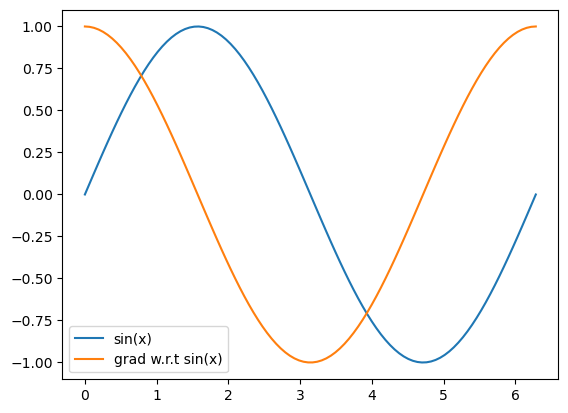

In [31]:
plt.plot(x.detach(), y.detach())
plt.plot(x.detach(), x.grad)
plt.legend(['sin(x)',"grad w.r.t sin(x)"])
plt.show()

In [33]:
import torch

torch.manual_seed(713)
x = torch.randn(size=(), requires_grad=True)
n1, n3, n5 = 1 / x, torch.sin(x), x ** 2
n4 = torch.log(n5)
n2 = n3 * n4
y = n1 + n2
y.backward()

x.grad, - 1 / x ** 2 + torch.cos(x) * torch.log(x ** 2) + 2 / x * torch.sin(x)


(tensor(-1.7580), tensor(-1.7580, grad_fn=<AddBackward0>))

In [20]:
import torch 
from torch.distributions.multinomial import Multinomial
fair_probs = torch.tensor([0.5,0.5])
counts = Multinomial(10, fair_probs).sample() / 10
counts

tensor([0.4000, 0.6000])

In [21]:
counts = Multinomial(100, fair_probs).sample() / 100
counts

tensor([0.4900, 0.5100])

In [22]:
counts = Multinomial(10000000, fair_probs).sample() / 10000000
counts

tensor([0.5001, 0.4999])

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
from torch.distributions.multinomial import Multinomial
import torch 

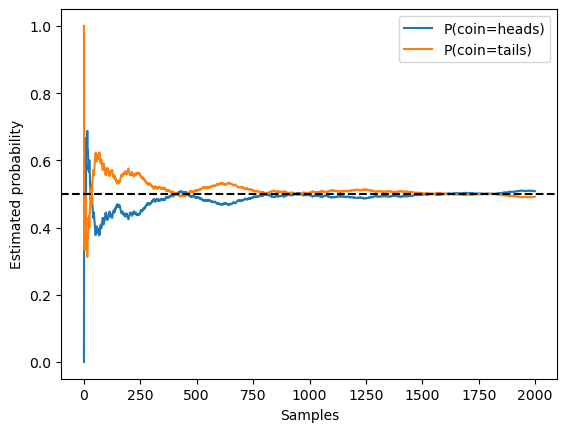

In [12]:
fair_probs = torch.tensor([0.5,0.5])
counts = Multinomial(1, fair_probs).sample((2000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

# d2l.set_figsize((4.5, 3.5))
plt.plot(estimates[:, 0], label=("P(coin=heads)"))
plt.plot(estimates[:, 1], label=("P(coin=tails)"))
plt.axhline(y=0.5, color='black', linestyle='dashed')
plt.xlabel('Samples')
plt.ylabel('Estimated probability')
plt.legend();

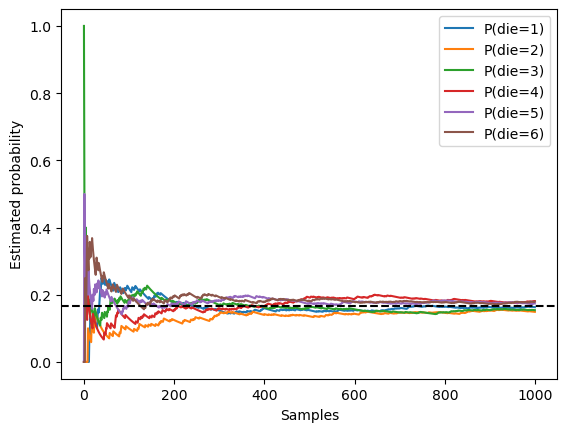

In [8]:
fair_probs = torch.tensor([0.1667,0.1667, 0.1667, 0.1667, 0.1667, 0.1667])
counts = Multinomial(1, fair_probs).sample((1000,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)
estimates = estimates.numpy()

# d2l.set_figsize((4.5, 3.5))
plt.plot(estimates[:, 0], label=("P(die=1)"))
plt.plot(estimates[:, 1], label=("P(die=2)"))
plt.plot(estimates[:, 2], label=("P(die=3)"))
plt.plot(estimates[:, 3], label=("P(die=4)"))
plt.plot(estimates[:, 4], label=("P(die=5)"))
plt.plot(estimates[:, 5], label=("P(die=6)"))

plt.axhline(y=0.16667, color='black', linestyle='dashed')
plt.xlabel('Samples')
plt.ylabel('Estimated probability')
plt.legend();

In [1]:
a = []
if not a:
    print("hello")

hello
